# Image OCR inspection

Inspect accepted vs rejected OCR from `image_ocr.json`.
Does not re-run OCR or create embeddings.

Prerequisite: `py src/doc_rag/9_image_ocr.py`

Uses `doc_rag.9_image_ocr.load_image_ocr_records`.

## 1. Setup

In [5]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display
from PIL import Image

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "doc_notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

image_ocr = importlib.reload(importlib.import_module("doc_rag.9_image_ocr"))

print("Processed root:", image_ocr.DEFAULT_PROCESSED_ROOT)
print("OCR schema version:", image_ocr.OCR_SCHEMA_VERSION)
print(
    "Quality defaults:",
    {
        "min_confidence": image_ocr.DEFAULT_MIN_CONFIDENCE,
        "min_mean_confidence": image_ocr.DEFAULT_MIN_MEAN_CONFIDENCE,
        "min_text_length": image_ocr.DEFAULT_MIN_TEXT_LENGTH,
        "min_meaningful_words": image_ocr.DEFAULT_MIN_MEANINGFUL_WORDS,
    },
)

Processed root: C:\Users\User\Desktop\inmind\gatherly_rag\data\rag\processed_documents
OCR schema version: 3
Quality defaults: {'min_confidence': 45.0, 'min_mean_confidence': 60.0, 'min_text_length': 6, 'min_meaningful_words': 3}


## 2. Load OCR results and coverage

In [6]:
records = image_ocr.load_image_ocr_records()
ocr_df = pd.DataFrame(records)

ocr_df["page_label"] = ocr_df["page_numbers"].apply(
    lambda pages: ", ".join(map(str, pages or []))
)
ocr_df["ocr_chars"] = ocr_df["ocr_text"].fillna("").astype(str).str.len()
ocr_df["has_vlm"] = (
    ocr_df["visual_description"].fillna("").astype(str).str.strip().ne("")
)

accepted = ocr_df[ocr_df["ocr_detected"]].copy()
rejected = ocr_df[~ocr_df["ocr_detected"]].copy()

print("Images:", len(ocr_df))
print("Accepted OCR:", len(accepted))
print("Rejected / no OCR:", len(rejected))
print("Documents:", ocr_df["file_name"].nunique())

summary = (
    ocr_df.groupby("file_name")
    .agg(
        images=("image_id", "size"),
        accepted=("ocr_detected", "sum"),
        median_conf=("ocr_mean_confidence", "median"),
        median_words=("ocr_word_count", "median"),
    )
    .reset_index()
)
summary["coverage"] = summary["accepted"] / summary["images"]
display(summary.sort_values(["coverage", "accepted"], ascending=False))

if not accepted.empty:
    display(
        accepted[["ocr_mean_confidence", "ocr_word_count", "ocr_chars"]].describe()
    )
else:
    print("No accepted OCR rows yet — inspect rejected samples below.")

Images: 480
Accepted OCR: 4
Rejected / no OCR: 476
Documents: 16


,file_name,images,accepted,median_conf,median_words,coverage
1,Celestial_Wedding.pdf,30,2,60.775,15.0,0.066667
2,Classic_Wedding.pdf,15,1,60.290,11.0,0.066667
9,Tropical_Wedding.pdf,21,1,62.115,8.0,0.047619
0,Boho_Wedding.pdf,47,0,61.920,9.0,0.000000
3,Enchanted_Forest_Wedding.pdf,10,0,61.580,15.5,0.000000
4,Garden_Wedding.pdf,52,0,59.060,8.5,0.000000
5,Modern_Wedding.pdf,51,0,62.190,4.0,0.000000
6,Moody_Wedding.pdf,34,0,62.700,11.5,0.000000
7,Romantic_Wedding.pdf,41,0,60.590,11.0,0.000000
8,Rustic_Wedding.pdf,54,0,60.165,3.0,0.000000


,ocr_mean_confidence,ocr_word_count,ocr_chars
count,4.000000,4.000000,4.00000
mean,75.522500,46.000000,188.00000
std,6.176414,16.990193,102.14369
min,66.350000,25.000000,67.00000
25%,74.630000,36.250000,122.50000
50%,78.150000,48.000000,200.00000
75%,79.042500,57.750000,265.50000
max,79.440000,63.000000,285.00000


## 3. Choose what to inspect

Edit filters, then run the display cell.
- `MODE="accepted"`: high-confidence accepted OCR
- `MODE="rejected_textish"`: rejected images whose nearby/VLM suggest readable text
- `MODE="document"`: one document only

In [7]:
MODE = "accepted"  # accepted / rejected_textish / document
SELECTED_DOCUMENT = "Boho_Wedding.pdf"  # used when MODE == "document"
MAX_IMAGES = 10
IMAGE_DISPLAY_WIDTH = 340

TEXTISH_TERMS = [
    "invitation",
    "menu",
    "card",
    "stationery",
    "sign",
    "program",
    "seating",
    "welcome",
    "text",
]
term_pattern = "|".join(TEXTISH_TERMS)

if MODE == "accepted":
    selected = accepted.sort_values(
        ["ocr_mean_confidence", "ocr_word_count"], ascending=False
    )
elif MODE == "rejected_textish":
    blob = (
        rejected["nearby_text"].fillna("").astype(str)
        + " "
        + rejected["visual_description"].fillna("").astype(str)
        + " "
        + rejected["section_title"].fillna("").astype(str)
    )
    selected = rejected[blob.str.contains(term_pattern, case=False, regex=True)].copy()
    selected = selected.sort_values(
        ["ocr_mean_confidence", "ocr_word_count"], ascending=False
    )
elif MODE == "document":
    selected = ocr_df[ocr_df["file_name"] == SELECTED_DOCUMENT].copy()
    selected = selected.sort_values(
        ["ocr_detected", "ocr_mean_confidence"], ascending=False
    )
else:
    raise ValueError(f"Unknown MODE: {MODE}")

selected = selected.head(MAX_IMAGES).reset_index(drop=True)
print("MODE:", MODE)
print("Selected:", len(selected))
display(
    selected[
        [
            "image_id",
            "file_name",
            "page_label",
            "ocr_detected",
            "ocr_word_count",
            "ocr_mean_confidence",
            "ocr_chars",
        ]
    ]
)

MODE: accepted
Selected: 4


,image_id,file_name,page_label,ocr_detected,ocr_word_count,ocr_mean_confidence,ocr_chars
0,Celestial_Wedding-8d87fb084c212175,Celestial_Wedding.pdf,1,True,63,79.44,285
1,Celestial_Wedding-2e417139e211df26,Celestial_Wedding.pdf,7,True,56,78.91,259
2,Tropical_Wedding-1fce0155dd4ac9ea,Tropical_Wedding.pdf,"3, 4",True,25,77.39,67
3,Classic_Wedding-304117f0ca3e2422,Classic_Wedding.pdf,6,True,40,66.35,141


## 4. Display image + nearby + VLM + OCR

### `Celestial_Wedding-8d87fb084c212175`  
**Document:** Celestial Wedding  
**Pages:** 1  
**Topic:** 1. Send Perfectly Aligned Invitations  
**OCR accepted:** True  
**Words / confidence:** 63 / 79.4

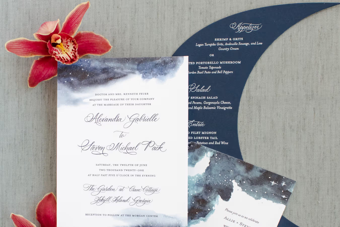

**Nearby PDF text**

1. Send Perfectly Aligned Invitations

photographer: Anna Shackleford | Tara Skinner Weddings & Events beautiful representation of your star-studded event. Your invitations are your guest's first glimpse into the theme of your wedding. Make sure they are a Creative Coverings


**VLM description**

The image showcases an elegant wedding invitation suite with a celestial watercolor design featuring shades of blue, white, and black. The invitation card displays formal script text detailing the marriage of Alexandra Gabrielle and Steven Michael Pack, set against a textured gray background adorned with pink orchids. A curved navy blue menu card lists appetizers, salads, and entrées, complementing the overall sophisticated and artistic layout.


**Accepted OCR text**

SHRIMP & GRITS
Logan Turnpike Grits, Andouille Sausage, and Low
Country Cream
PORTOBELLO MUSHROOM
Tomato Tapenade
fen Basil Pesto and Bell Peppers
SALAD
Pecans, Gorgonzola Cheese,
ind Maple Balsamic Vinaigrette
Levandia
FILET MIGNON
LOBSTER TAIL
and Red Wine
lane
Mage
HE MORGAN CENTER






### `Celestial_Wedding-2e417139e211df26`  
**Document:** Celestial Wedding  
**Pages:** 7  
**Topic:** 6. Keep The Theme Going With Food & Drink  
**OCR accepted:** True  
**Words / confidence:** 56 / 78.9

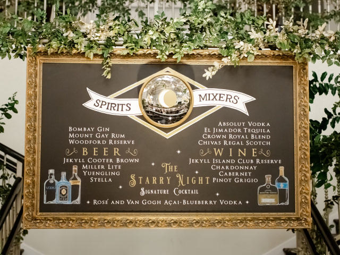

**Nearby PDF text**

6. Keep The Theme Going With Food & Drink

photographer: Anna Shackleford | Tara Skinner Weddings & Events incorporate your theme into every aspect of your wedding.


**VLM description**

A decorative gold-framed chalkboard menu displays various spirits, mixers, beers, wines, and a signature cocktail against a dark background with elegant white lettering. The board is adorned with greenery and white flowers at the top, creating a festive atmosphere. Small images of bottles accompany the drink categories, enhancing the visual appeal. The setting appears to be indoors, near a staircase with white railings.


**Accepted OCR text**

SPIRITS \
BOMBAY GIN,
Et JIMADOR TEQUILA
MOUNT GaY RUM
WOODFORD RESERVE
(Chivas REGAL Scorch
CROWN ROYAL BLEND
JEKYLL COOTER BROWN
JEKYLL ISLAND RESERVE
g MILLER
CHARDONNAY
YUENGLING
STELLA
CABERNET
NOT GRIGIO
Starry
+ ROSE AND VAN GOGH AGAI-BLUEBERRY VODKA +






### `Tropical_Wedding-1fce0155dd4ac9ea`  
**Document:** Tropical Wedding  
**Pages:** 3, 4  
**Topic:** 2. Set the Tone With Tropical Wedding Invitations  
**OCR accepted:** True  
**Words / confidence:** 25 / 77.4

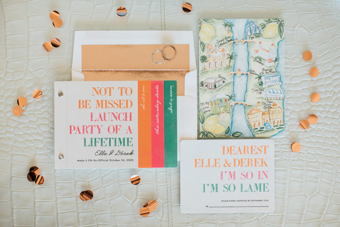

**Nearby PDF text**

2. Set the Tone With Tropical Wedding Invitations

photographer: Stanlo Photography | KeAira Chantell Events SEE MORE filters to narrow your search. your invitations and print company with PartySlate's curated vendor directory.


**VLM description**

The image showcases a vibrant invitation suite with colorful cards featuring playful fonts and phrases like "NOT TO BE MISSED LAUNCH PARTY OF A LIFETIME" and "DEAREST ELLE & DEREK." A hand-drawn map with lemon illustrations and gold confetti adds a whimsical touch, all arranged on a textured white surface. The design incorporates bright orange, pink, green, and blue hues, creating an eye-catching and celebratory visual style.


**Accepted OCR text**

BE MISSED
itty
LAUNCH
vend
PARTY OF A
LIFETIME
DEAREST
ELLE & DEREK






### `Classic_Wedding-304117f0ca3e2422`  
**Document:** Classic Wedding  
**Pages:** 6  
**Topic:** 3. Incorporate Timeless Details From the Beginning  
**OCR accepted:** True  
**Words / confidence:** 40 / 66.3

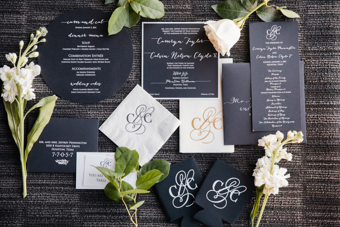

**Nearby PDF text**

3. Incorporate Timeless Details From the Beginning

EXPLORE PARTYSLATE PRO photographer: Akil Bennett Photography | Grayhouse Events Atelier 4. Choose A Quintessential Wedding Arch Classic squared arches are a timeless look. You have the option to modernize it with your florals


**VLM description**

The image showcases a sophisticated wedding invitation suite with a monochromatic black and white theme. The layout includes various cards and napkins, each featuring elegant calligraphy and monograms. The text on the cards indicates wedding details such as the date, location, and names of the couple. The suite is adorned with fresh white flowers and greenery, adding a natural touch to the elegant design. The materials appear to be high-quality paper, and the overall style is formal and elegant, suitable for a sophisticated wedding event.


**Accepted OCR text**

calf
mene
sour
rows | | FTL
COMBINATION ENTREE
owe ust nore
Phen
bien
More
AND MRS. JEFFREY PENNINGTON.
1010 B NANTUCKET DRIVE
HOUSTON. Texas






In [8]:
def show_ocr_record(row, width=340):
    conf = row.get("ocr_mean_confidence")
    conf_label = "None" if pd.isna(conf) else f"{float(conf):.1f}"
    headings = row.get("heading_path") or []
    if isinstance(headings, str):
        headings = [headings]

    display(Markdown(
        f"### `{row['image_id']}`  \n"
        f"**Document:** {row.get('document_label') or row['file_name']}  \n"
        f"**Pages:** {row['page_label']}  \n"
        f"**Topic:** {' → '.join(map(str, headings))}  \n"
        f"**OCR accepted:** {bool(row['ocr_detected'])}  \n"
        f"**Words / confidence:** {row.get('ocr_word_count', 0)} / {conf_label}"
    ))

    image_path = Path(row["image_path"])
    if image_path.is_file():
        with Image.open(image_path) as image:
            height = max(1, round(image.height * width / image.width))
            display(image.copy().resize((width, height)))
    else:
        display(Markdown(f"**Missing image:** `{image_path}`"))

    display(Markdown("**Nearby PDF text**"))
    print(str(row.get("nearby_text") or "").strip() or "(empty)")

    display(Markdown("**VLM description**"))
    print(str(row.get("visual_description") or "").strip() or "(empty)")

    display(Markdown("**Accepted OCR text**"))
    print(str(row.get("ocr_text") or "").strip() or "(none accepted)")

    if not row["ocr_detected"]:
        raw = str(row.get("ocr_raw_text") or "").strip()
        reasons = row.get("ocr_rejection_reasons") or []
        display(Markdown("**Rejected raw OCR**"))
        print(raw or "(empty raw)")
        print("Rejection reasons:", reasons)

    print("\n\n\n")


if selected.empty:
    print("Nothing to display for this MODE/filter.")
else:
    for _, row in selected.iterrows():
        show_ocr_record(row, IMAGE_DISPLAY_WIDTH)